<div style=" background-color: #3D839B;" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">PROJET DATA ANALYST</h1>
<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">Analysez les ventes d'une librairie 
</h2>
</div>

<div style="background-color:#3D839B ;" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Step 1 - Import and Loading Excel files</h2>
</div>

<div style="border: 1px solid #224F59;" >
<h3 style="margin: auto; padding: 20px; color: #224F59; ">1.1 - Import of bookstores</h3>
</div>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from datetime import datetime
import warnings
import scipy.stats as st
from scipy.stats import shapiro
import statsmodels.api as sm
from statsmodels.formula.api import ols
warnings.filterwarnings('ignore')

<div style="border: 1px solid #224F59;" >
<h3 style="margin: auto; padding: 20px; color: #224F59; ">1.2 - Loading Excel files</h3>
</div>

In [8]:
ls

Analysez les ventes.pptx  Analysez_librairie.xlsx   products.csv
Analysez_librairie.ipynb  customers.csv             Transactions.csv


In [9]:
 products = pd.read_csv("products.csv",sep=';')

In [10]:
Transactions = pd.read_csv(
    "Transactions.csv",
    sep=';',
    dtype={
        "id_prod": str,
        "session_id": str,
        "client_id": str
    },
    parse_dates=["date"]
)

In [11]:
customers= pd.read_csv("customers.csv",sep=';')

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.1 - Analyse exploratoire du fichier  products</h3>
</div>

In [12]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3286 entries, 0 to 3285
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id_prod  3286 non-null   object 
 1   price    3286 non-null   float64
 2   categ    3286 non-null   int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 77.1+ KB


In [13]:
products.head()

,id_prod,price,categ
0,0_1421,19.99,0
1,0_1368,5.13,0
2,0_731,17.99,0
3,1_587,4.99,1
4,0_1507,3.99,0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.2 - Analyse exploratoire du fichier Transactions </h3>
</div>

In [14]:
Transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 687534 entries, 0 to 687533
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   id_prod     687534 non-null  object        
 1   date        687534 non-null  datetime64[ns]
 2   session_id  687534 non-null  object        
 3   client_id   687534 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 21.0+ MB


In [15]:
Transactions.head()


,id_prod,date,session_id,client_id
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier customers </h3>
</div>

In [16]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8621 entries, 0 to 8620
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  8621 non-null   object
 1   sex        8621 non-null   object
 2   birth      8621 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 202.2+ KB


In [17]:
customers.head()

,client_id,sex,birth
0,c_4410,f,1967
1,c_7839,f,1975
2,c_1699,f,1984
3,c_5961,f,1962
4,c_5320,m,1943


In [18]:
print(customers[customers["client_id"] == "c_4410"])


  client_id sex  birth
0    c_4410   f   1967


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">Fusion des fichiers
 </h3>
</div>

In [19]:
df_tra_pro = Transactions.merge(products, on='id_prod', how='left', indicator=True)

In [20]:
df_tra_pro = df_tra_pro.drop(columns=['_merge'], errors='ignore')


In [21]:
df = df_tra_pro.merge(customers, on='client_id', how='left', indicator=True)

In [22]:
df['_merge'].unique().tolist()

['both']

In [23]:
print("Données fusionnées:")
display(df.head())

Données fusionnées:


,id_prod,date,session_id,client_id,price,categ,sex,birth,_merge
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,11.99,0,f,1967,both
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,19.37,0,m,1960,both
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,4.50,0,m,1988,both
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,6.55,0,f,1989,both
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,16.49,0,f,1956,both


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">Création des colonnes supplémentaire
 </h3>
</div>

In [24]:
df['ca'] = df['price'] 


df['jour'] = df['date'].dt.date


In [25]:
df = df.dropna(subset=['date'])

df['semaine'] = df['date'].dt.to_period('W').dt.start_time
df['mois'] = df['date'].dt.to_period('M').dt.start_time

In [26]:
print("Données fusionnées:")
display(df.head())

Données fusionnées:


,id_prod,date,session_id,client_id,price,categ,sex,birth,_merge,ca,jour,semaine,mois
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,11.99,0,f,1967,both,11.99,2021-03-01,2021-03-01,2021-03-01
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,19.37,0,m,1960,both,19.37,2021-03-01,2021-03-01,2021-03-01
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,4.50,0,m,1988,both,4.50,2021-03-01,2021-03-01,2021-03-01
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,6.55,0,f,1989,both,6.55,2021-03-01,2021-03-01,2021-03-01
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,16.49,0,f,1956,both,16.49,2021-03-01,2021-03-01,2021-03-01


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 687534 entries, 0 to 687533
Data columns (total 13 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   id_prod     687534 non-null  object        
 1   date        687534 non-null  datetime64[ns]
 2   session_id  687534 non-null  object        
 3   client_id   687534 non-null  object        
 4   price       687534 non-null  float64       
 5   categ       687534 non-null  int64         
 6   sex         687534 non-null  object        
 7   birth       687534 non-null  int64         
 8   _merge      687534 non-null  category      
 9   ca          687534 non-null  float64       
 10  jour        687534 non-null  object        
 11  semaine     687534 non-null  datetime64[ns]
 12  mois        687534 non-null  datetime64[ns]
dtypes: category(1), datetime64[ns](3), float64(2), int64(2), object(5)
memory usage: 63.6+ MB


In [28]:
df['categ'] = df['categ'].astype(int)      
df['birth'] = df['birth'].astype(int)     
df['sex'] = df['sex'].astype('category')  
df['categ'] = df['categ'].astype('category')  


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 687534 entries, 0 to 687533
Data columns (total 13 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   id_prod     687534 non-null  object        
 1   date        687534 non-null  datetime64[ns]
 2   session_id  687534 non-null  object        
 3   client_id   687534 non-null  object        
 4   price       687534 non-null  float64       
 5   categ       687534 non-null  category      
 6   sex         687534 non-null  category      
 7   birth       687534 non-null  int64         
 8   _merge      687534 non-null  category      
 9   ca          687534 non-null  float64       
 10  jour        687534 non-null  object        
 11  semaine     687534 non-null  datetime64[ns]
 12  mois        687534 non-null  datetime64[ns]
dtypes: category(3), datetime64[ns](3), float64(2), int64(1), object(4)
memory usage: 54.4+ MB


In [30]:
df.head()

,id_prod,date,session_id,client_id,price,categ,sex,birth,_merge,ca,jour,semaine,mois
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,11.99,0,f,1967,both,11.99,2021-03-01,2021-03-01,2021-03-01
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,19.37,0,m,1960,both,19.37,2021-03-01,2021-03-01,2021-03-01
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,4.50,0,m,1988,both,4.50,2021-03-01,2021-03-01,2021-03-01
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,6.55,0,f,1989,both,6.55,2021-03-01,2021-03-01,2021-03-01
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,16.49,0,f,1956,both,16.49,2021-03-01,2021-03-01,2021-03-01


<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Analyse du chiffre d'affaires (CA)</h2>
</div>

In [31]:
customers_transactions_with_price_2021 = df[df['date'] < '2022-01-01 00:00:00.000000']
customers_transactions_with_price_2022 = df[(df['date'] < '2023-01-01 00:00:00.000000') & (df['date'] >= '2022-01-01 00:00:00.000000')]
customers_transactions_with_price_2023 = df[(df['date'] < '2024-01-01 00:00:00.000000') & (df['date'] >= '2023-01-01 00:00:00.000000')]

In [32]:
CA_2021 = customers_transactions_with_price_2021['price'].sum()
CA_2022 = customers_transactions_with_price_2022['price'].sum()
CA_2023 = customers_transactions_with_price_2023['price'].sum()
print("Chiffre d'affaire 2021 :", round(CA_2021,2), '€')
print("Chiffre d'affaire 2022 :",round(CA_2022,2), '€')
print("Chiffre d'affaire 2023 :",round(CA_2023,2), '€')

Chiffre d'affaire 2021 : 4944760.98 €
Chiffre d'affaire 2022 : 6108681.81 €
Chiffre d'affaire 2023 : 974220.31 €


In [33]:
print("Chiffre d'affaire total :", round(CA_2021 + CA_2022 + CA_2023,2), '€')

Chiffre d'affaire total : 12027663.1 €


<div style="border: 1px solid #224F59;" >
<h3 style="margin: auto; padding: 20px; color: #224F59; ">3.1 – Évolution du chiffre d’affaires par jour (avec moyenne mobile 7 jours)</h3>
</div>

In [34]:
daily_ca = df.groupby('jour')['ca'].sum().reset_index()

# Moyenne mobile sur 7 jours
daily_ca['moyenne_mobile'] = daily_ca['ca'].rolling(window=7).mean()

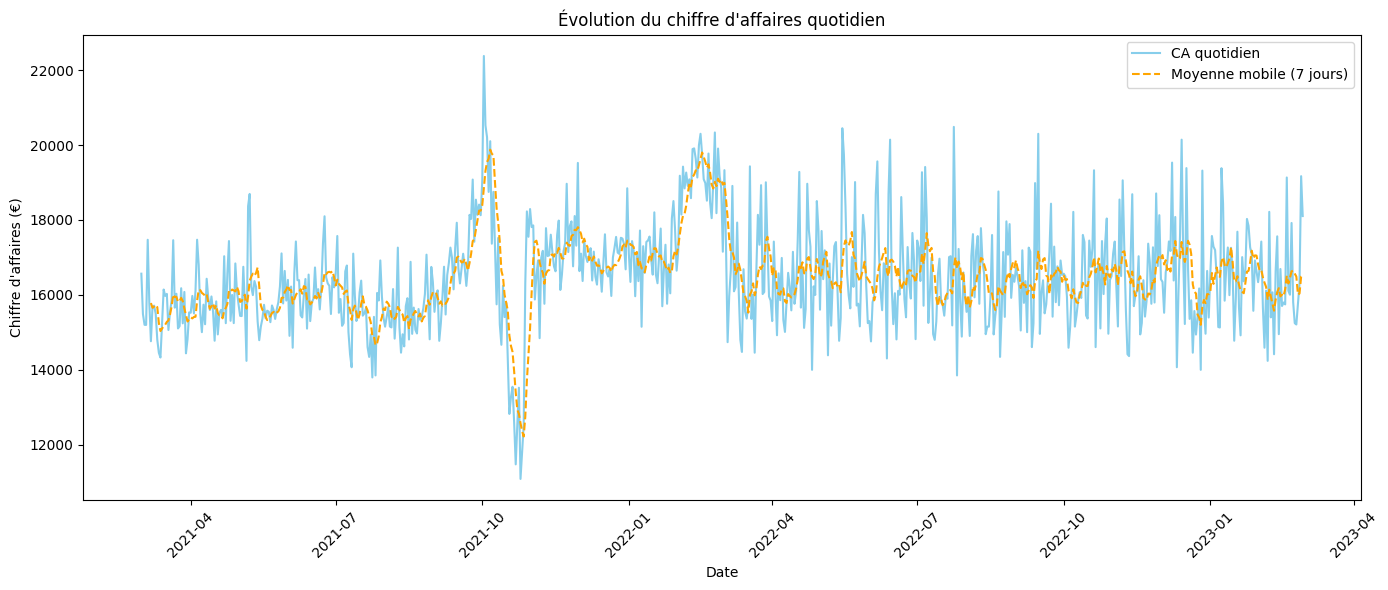

In [35]:
plt.figure(figsize=(14,6))
plt.plot(daily_ca['jour'], daily_ca['ca'], label='CA quotidien', color='skyblue')
plt.plot(daily_ca['jour'], daily_ca['moyenne_mobile'], label='Moyenne mobile (7 jours)', color='orange', linestyle='--')
plt.title("Évolution du chiffre d'affaires quotidien")
plt.xlabel("Date")
plt.ylabel("Chiffre d'affaires (€)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<div style="border: 1px solid #224F59;" >
<h3 style="margin: auto; padding: 20px; color: #224F59; "> 
 3.2 – Évolution du CA par semaine et par mois</h3>
</div>

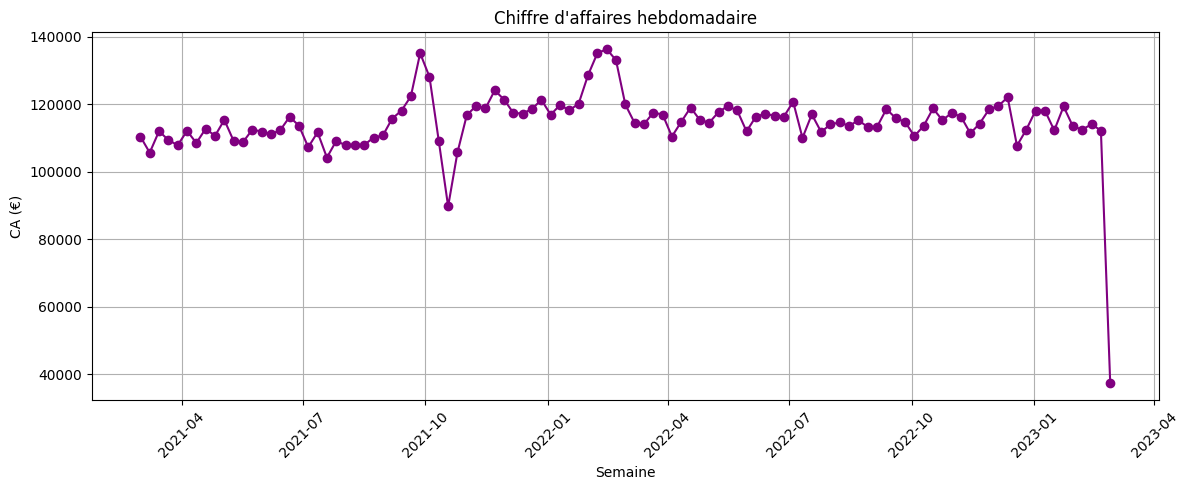

In [36]:
# Hebdomadaire
weekly_ca = df.groupby('semaine')['ca'].sum().reset_index()

plt.figure(figsize=(12,5))
plt.plot(weekly_ca['semaine'], weekly_ca['ca'], marker='o', color='purple')
plt.title("Chiffre d'affaires hebdomadaire")
plt.xlabel("Semaine")
plt.ylabel("CA (€)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

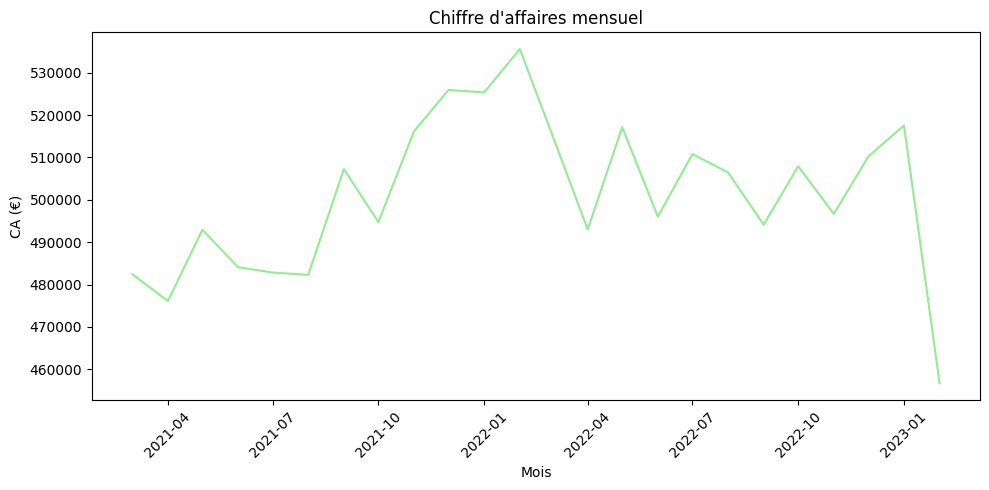

In [37]:
# Mensuel
monthly_ca = df.groupby('mois')['ca'].sum().reset_index()

plt.figure(figsize=(10,5))
plt.plot(monthly_ca['mois'], monthly_ca['ca'], color='lightgreen')
plt.title("Chiffre d'affaires mensuel")
plt.xlabel("Mois")
plt.ylabel("CA (€)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; "> Étape 3.2 – Analyse du chiffre d'affaires par catégorie</h2>
</div>

<div style="border: 1px solid #224F59;" >
<h3 style="margin: auto; padding: 20px; color: #224F59; ">  1. Calcul du chiffre d'affaires par catégorie</h3>
</div>

In [38]:
# Agrégation CA par catégorie

ca_par_categ = df.groupby('categ', observed=True)['ca'].sum().reset_index()


ca_par_categ = ca_par_categ.sort_values(by='ca', ascending=False)


print("Chiffre d'affaires par catégorie:")
display(ca_par_categ)


Chiffre d'affaires par catégorie:


,categ,ca
1,1,4827657.11
0,0,4419730.97
2,2,2780275.02


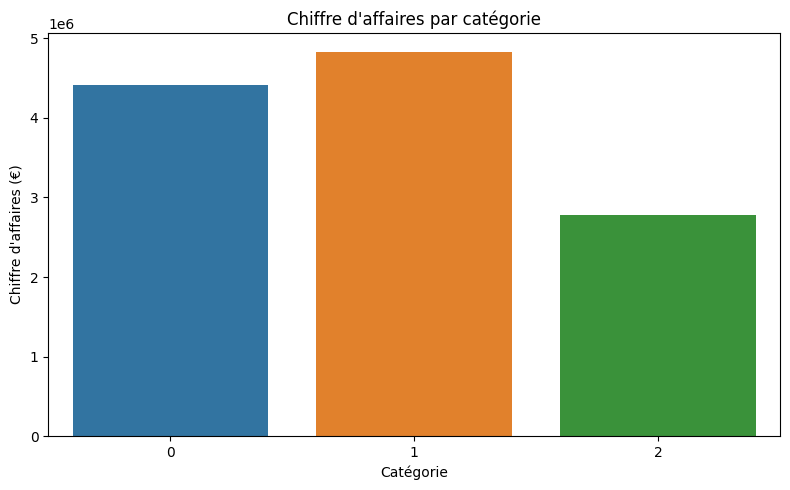

In [39]:
plt.figure(figsize=(8,5))
sns.barplot(data=ca_par_categ, x='categ', y='ca')
plt.title("Chiffre d'affaires par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("Chiffre d'affaires (€)")
plt.tight_layout()
plt.show()


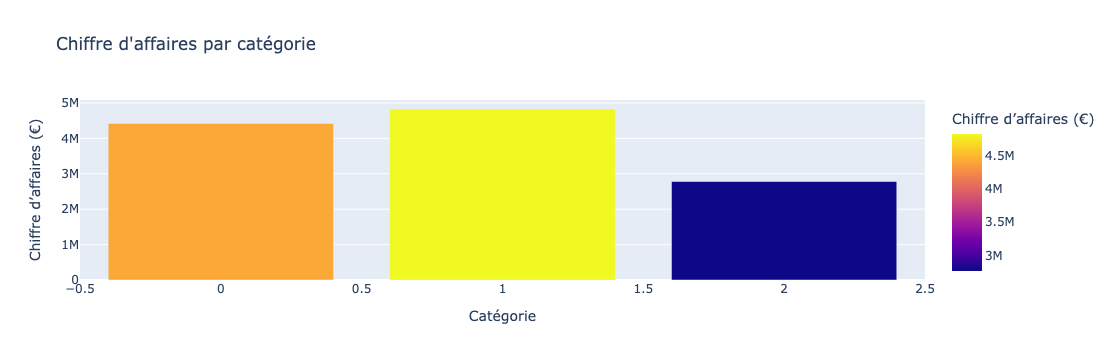

In [40]:

fig = px.bar(
    ca_par_categ,
    x='categ',
    y='ca',
    title="Chiffre d'affaires par catégorie",
    labels={'categ': 'Catégorie', 'ca': 'Chiffre d’affaires (€)'},
    color='ca'
)
fig.show()


<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; "> 
 Étape 3.3 – Nombre de clients, produits et transactions par mois </h2>
</div>

<div style="border: 1px solid #224F59;" >
<h3 style="margin: auto; padding: 20px; color: #224F59; "> 
📌 1. Préparation des indicateurs par mois</h3>
</div>

In [41]:
# Agrégation mensuelle
kpis_mensuels = df.groupby('mois').agg(
    ca_total=('ca', 'sum'),
    nb_clients=('client_id', 'nunique'),
    nb_transactions=('session_id', 'nunique'),
    nb_produits=('id_prod', 'count')
).reset_index()


display(kpis_mensuels.head())


,mois,ca_total,nb_clients,nb_transactions,nb_produits
0,2021-03-01,482440.61,5676,14201,28601
1,2021-04-01,476109.30,5674,13970,28443
2,2021-05-01,492943.47,5644,14168,28285
3,2021-06-01,484088.56,5659,13838,26850
4,2021-07-01,482835.40,5672,13571,24738


<div style="border: 1px solid #224F59;" >
<h3 style="margin: auto; padding: 20px; color: #224F59; "> 
2. Visualisation – Clients, Transactions, Produits
</h3>
</div>

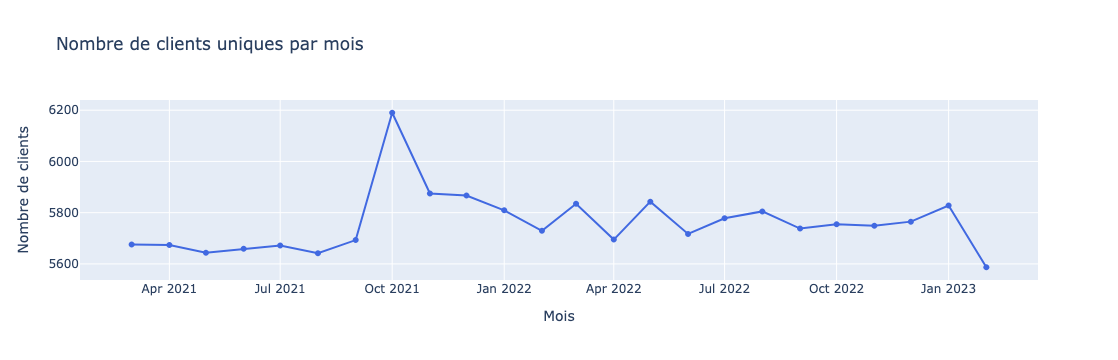

In [42]:
fig = px.line(
    kpis_mensuels,
    x='mois',
    y='nb_clients',
    title='Nombre de clients uniques par mois',
    labels={'mois': 'Mois', 'nb_clients': 'Nombre de clients'},
    markers=True
)
fig.update_traces(line=dict(color='royalblue'))
fig.show()



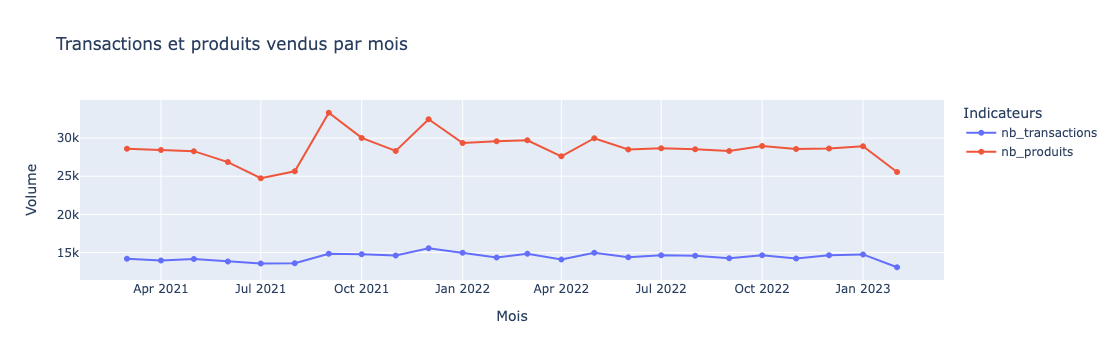

In [43]:
fig = px.line(
    kpis_mensuels,
    x='mois',
    y=['nb_transactions', 'nb_produits'],
    title="Transactions et produits vendus par mois",
    labels={
        'mois': 'Mois',
        'value': 'Volume',
        'variable': 'Indicateur'
    },
    markers=True
)
fig.update_layout(legend_title_text='Indicateurs')
fig.show()


<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; "> 
Étape 3.4 – Analyse des Top et Flop produits
 </h2>
</div>

<div style="border: 1px solid #224F59;" >
<h3 style="margin: auto; padding: 20px; color: #224F59; ">1. Calcul du chiffre d'affaires et ventes par produit</h3>
</div>

In [44]:
# Regrouper par produit
produits_stats = df.groupby('id_prod').agg(
    nb_ventes=('id_prod', 'count'),
    ca_total=('ca', 'sum')
).reset_index()

# les tops et flops
top_produits = produits_stats.sort_values(by='ca_total', ascending=False).head(10)
flop_produits = produits_stats.sort_values(by='ca_total', ascending=True).head(10)


print("Top produits par chiffre d'affaires:")
display(top_produits)

print("Flop produits par chiffre d'affaires:")
display(flop_produits)


Top produits par chiffre d'affaires:


,id_prod,nb_ventes,ca_total
3096,2_159,650,94893.50
3070,2_135,1005,69334.95
3045,2_112,968,65407.76
3034,2_102,1027,60736.78
3152,2_209,814,56971.86
2619,1_395,1953,56617.47
2591,1_369,2340,56136.60
3043,2_110,865,53846.25
2607,1_383,1857,53834.43
2641,1_414,2246,53522.18


Flop produits par chiffre d'affaires:


,id_prod,nb_ventes,ca_total
595,0_1539,1,0.99
313,0_1284,1,1.38
719,0_1653,2,1.98
1784,0_541,1,1.99
665,0_1601,1,1.99
2079,0_807,1,1.99
802,0_1728,1,2.27
549,0_1498,1,2.48
2179,0_898,2,2.54
925,0_1840,2,2.56


<div style="border: 1px solid #224F59;" >
<h3 style="margin: auto; padding: 20px; color: #224F59; ">2. Visualisation des Top produits</h3>
</div>

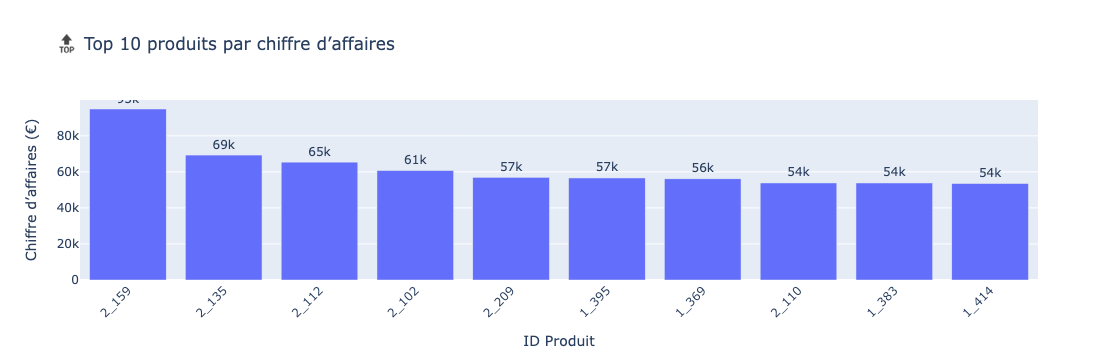

In [45]:
fig = px.bar(
    top_produits,
    x='id_prod',
    y='ca_total',
    title="🔝 Top 10 produits par chiffre d’affaires",
    labels={'id_prod': 'ID Produit', 'ca_total': 'Chiffre d’affaires (€)'},
    text='ca_total'
)
fig.update_traces(texttemplate='%{text:.2s}', textposition='outside')
fig.update_layout(xaxis_tickangle=-45)
fig.show()

<div style="border: 1px solid #224F59;" >
<h3 style="margin: auto; padding: 20px; color: #224F59; "> 3. Visualisation des Flop produits</h3>
</div>

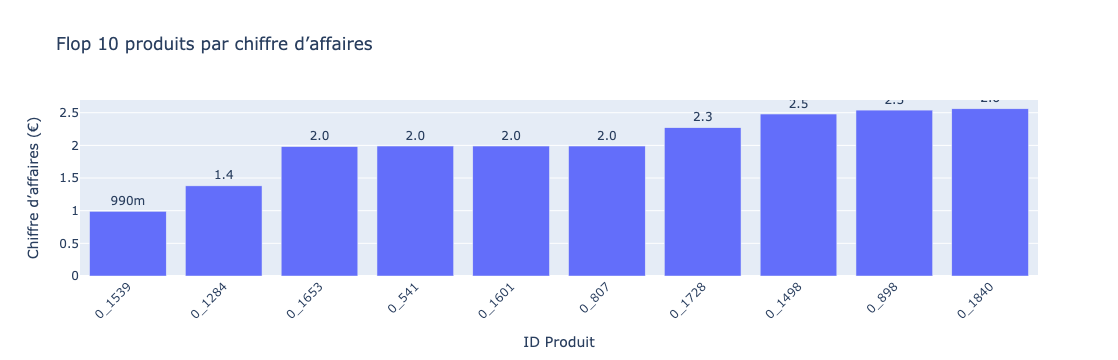

In [46]:
fig = px.bar(
    flop_produits,
    x='id_prod',
    y='ca_total',
    title="Flop 10 produits par chiffre d’affaires",
    labels={'id_prod': 'ID Produit', 'ca_total': 'Chiffre d’affaires (€)'},
    text='ca_total'
)
fig.update_traces(texttemplate='%{text:.2s}', textposition='outside')
fig.update_layout(xaxis_tickangle=-45)
fig.show()


<div style="border: 1px solid #224F59;" >
<h3 style="margin: auto; padding: 20px; color: #224F59; "> 
 Répartition des Top produits par catégorie</h3>
</div>

In [47]:
# Merge pour ajouter la catégorie aux top et flop produits
top_produits = top_produits.merge(products[['id_prod', 'categ']], on='id_prod', how='left')
flop_produits = flop_produits.merge(products[['id_prod', 'categ']], on='id_prod', how='left')


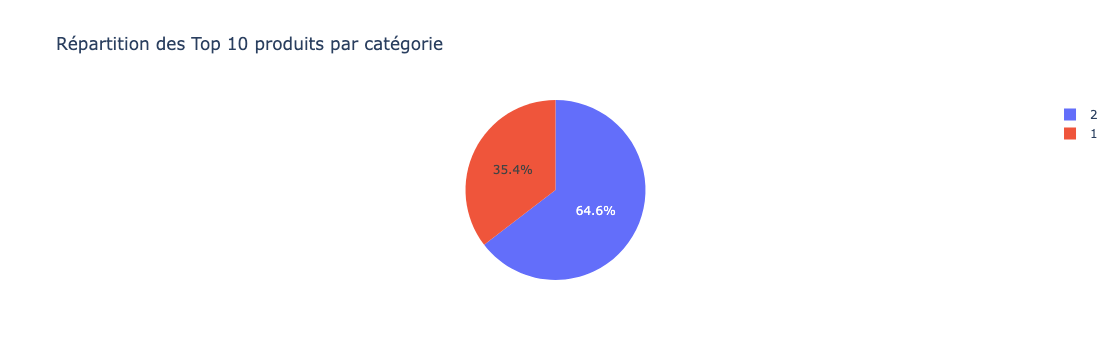

In [48]:
top_par_categ = top_produits.groupby('categ')['ca_total'].sum().reset_index()

fig = px.pie(
    top_par_categ,
    values='ca_total',
    names='categ',
    title="Répartition des Top 10 produits par catégorie"
)
fig.show()


<div style="border: 1px solid #224F59;" >
<h3 style="margin: auto; padding: 20px; color: #224F59; "> 
 Répartition des Flop produits par catégorie</h3>
</div>

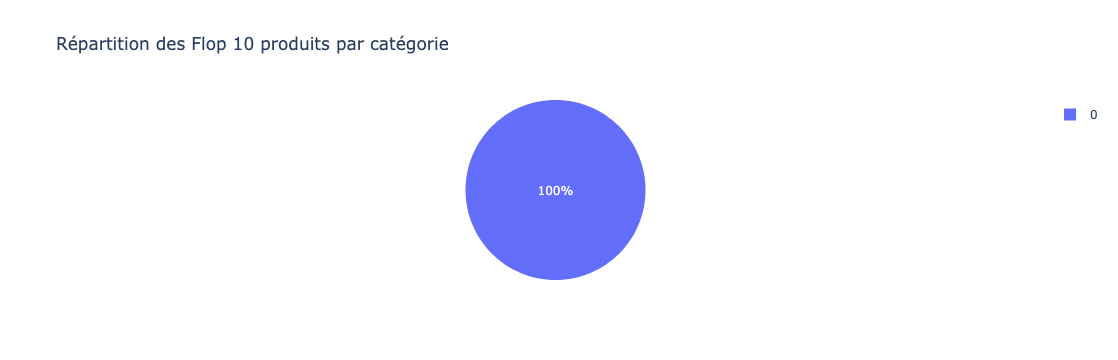

In [49]:
flop_par_categ = flop_produits.groupby('categ')['ca_total'].sum().reset_index()

fig = px.pie(
    flop_par_categ,
    values='ca_total',
    names='categ',
    title="Répartition des Flop 10 produits par catégorie"
)
fig.show()


<div style="border: 1px solid #224F59;" >
<h3 style="margin: auto; padding: 20px; color: #224F59; "> 
 Top produits par catégorie individuelle</h3>
</div>

In [50]:
top_produits = top_produits.merge(products[['id_prod', 'categ']], on='id_prod', how='left')


In [51]:
print(top_produits.head())


  id_prod  nb_ventes  ca_total  categ_x  categ_y
0   2_159        650  94893.50        2        2
1   2_135       1005  69334.95        2        2
2   2_112        968  65407.76        2        2
3   2_102       1027  60736.78        2        2
4   2_209        814  56971.86        2        2


In [52]:
print(top_produits.columns)


Index(['id_prod', 'nb_ventes', 'ca_total', 'categ_x', 'categ_y'], dtype='object')


In [53]:
(top_produits['categ_x'] == top_produits['categ_y']).all()


True

In [54]:
top_produits['categ'] = top_produits['categ_x']  # أو 'categ_y'


In [55]:
top_par_categ = top_produits.sort_values('ca_total', ascending=False).groupby('categ').head(1).reset_index(drop=True)
display(top_par_categ)



,id_prod,nb_ventes,ca_total,categ_x,categ_y,categ
0,2_159,650,94893.50,2,2,2
1,1_395,1953,56617.47,1,1,1


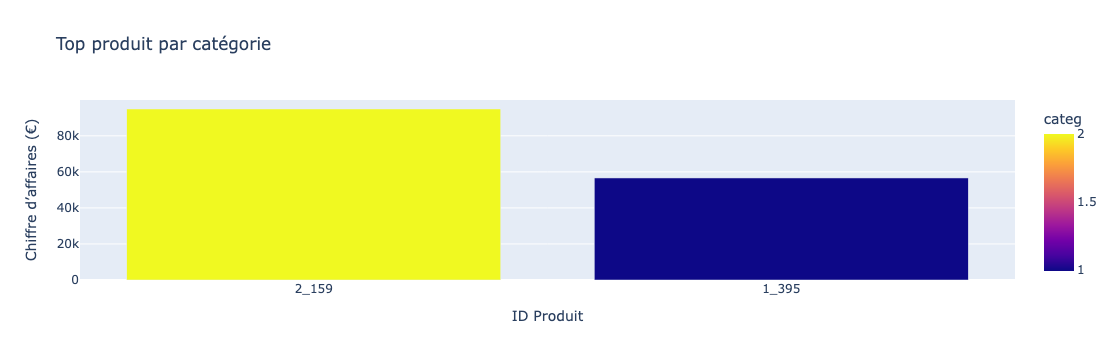

In [56]:
fig = px.bar(
    top_par_categ,
    x='id_prod',
    y='ca_total',
    color='categ',
    title='Top produit par catégorie',
    labels={'id_prod': 'ID Produit', 'ca_total': 'Chiffre d’affaires (€)'}
)

fig.show()


<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; "> 
Chiffre d'affaires avec la moyenne mobile
 </h2>
</div>

In [57]:
print(df.columns)


Index(['id_prod', 'date', 'session_id', 'client_id', 'price', 'categ', 'sex',
       'birth', '_merge', 'ca', 'jour', 'semaine', 'mois'],
      dtype='object')


In [58]:
print(df.head())


  id_prod                       date session_id client_id  price categ sex  \
0  0_1259 2021-03-01 00:01:07.843138        s_1     c_329  11.99     0   f   
1  0_1390 2021-03-01 00:02:26.047414        s_2     c_664  19.37     0   m   
2  0_1352 2021-03-01 00:02:38.311413        s_3     c_580   4.50     0   m   
3  0_1458 2021-03-01 00:04:54.559692        s_4    c_7912   6.55     0   f   
4  0_1358 2021-03-01 00:05:18.801198        s_5    c_2033  16.49     0   f   

   birth _merge     ca        jour    semaine       mois  
0   1967   both  11.99  2021-03-01 2021-03-01 2021-03-01  
1   1960   both  19.37  2021-03-01 2021-03-01 2021-03-01  
2   1988   both   4.50  2021-03-01 2021-03-01 2021-03-01  
3   1989   both   6.55  2021-03-01 2021-03-01 2021-03-01  
4   1956   both  16.49  2021-03-01 2021-03-01 2021-03-01  


In [59]:
df['jour'] = df['date'].dt.date 

In [60]:
df['ca'] = df['price']

In [61]:
# Grouper les données par jour
ca_journalier = df.groupby('jour')['ca'].sum().reset_index()

# Ajouter la moyenne mobile (7 jours)
ca_journalier['ca_moyenne_mobile'] = ca_journalier['ca'].rolling(window=7).mean()



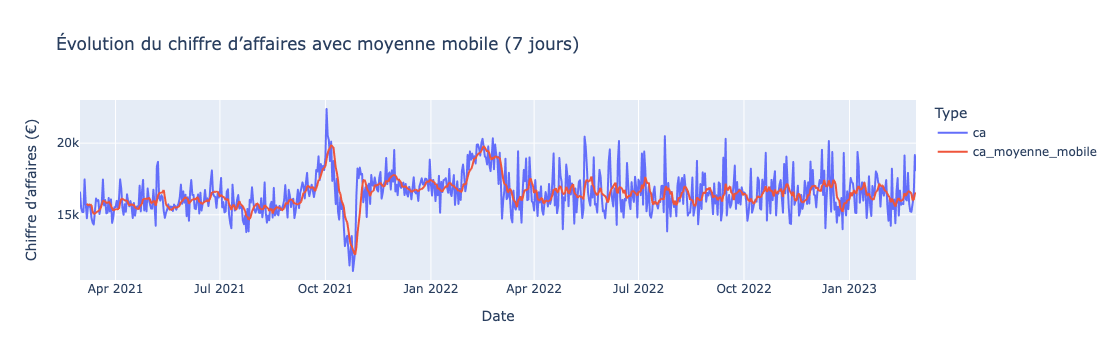

In [62]:
fig = px.line(
    ca_journalier,
    x='jour',
    y=['ca', 'ca_moyenne_mobile'],
    labels={'value': 'Chiffre d’affaires (€)', 'jour': 'Date'},
    title='Évolution du chiffre d’affaires avec moyenne mobile (7 jours)'
)
fig.update_layout(legend_title_text='Type')
fig.show()


<div style="border: 1px solid #224F59;" >
<h3 style="margin: auto; padding: 20px; color: #224F59; "> 3. Fraud Detection – Detect Unusual Purchase Patterns</h3>
</div>

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; "> 
Analyse du lien entre le sexe des clients et les catégories de livres achetés </h2>
</div>

In [63]:
#alcule le nombre d’achats pour chaque combinaison de sexe et de catégorie
sex_categ = df.groupby(['sex', 'categ'])['id_prod'].count().reset_index()
sex_categ.rename(columns={'id_prod': 'nb_achats'}, inplace=True)
display(sex_categ)


,sex,categ,nb_achats
0,f,0,206103
1,f,1,119307
2,f,2,17283
3,m,0,209356
4,m,1,116285
5,m,2,19200


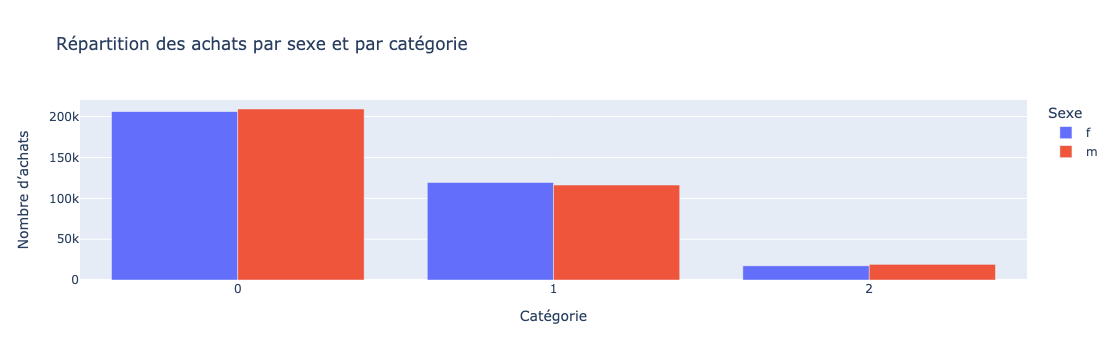

In [64]:

fig = px.bar(
    sex_categ,
    x='categ',
    y='nb_achats',
    color='sex',
    barmode='group',
    title="Répartition des achats par sexe et par catégorie",
    labels={'nb_achats': 'Nombre d’achats', 'categ': 'Catégorie', 'sex': 'Sexe'}
)
fig.show()


<div style="border: 1px solid #224F59;" >
<h3 style="margin: auto; padding: 20px; color: #224F59; "> Calcul des pourcentages</h3>
</div>

In [65]:
sex_categ = df.groupby(['sex', 'categ'])['id_prod'].count().reset_index()
sex_categ.rename(columns={'id_prod': 'nb_achats'}, inplace=True)


In [66]:
sex_total = sex_categ.groupby('sex')['nb_achats'].transform('sum')

sex_categ['pct'] = round(100 * sex_categ['nb_achats'] / sex_total, 1)
display(sex_categ)


,sex,categ,nb_achats,pct
0,f,0,206103,60.1
1,f,1,119307,34.8
2,f,2,17283,5.0
3,m,0,209356,60.7
4,m,1,116285,33.7
5,m,2,19200,5.6


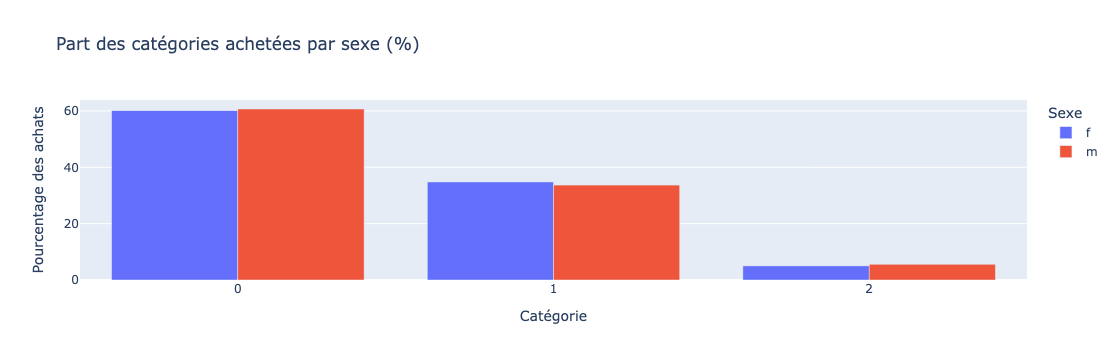

In [67]:
fig = px.bar(
    sex_categ,
    x='categ',
    y='pct',
    color='sex',
    barmode='group',
    title="Part des catégories achetées par sexe (%)",
    labels={'pct': 'Pourcentage des achats', 'categ': 'Catégorie', 'sex': 'Sexe'}
)
fig.show()


<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; "> 
Analyse du lien entre l’âge des clients et le montant total des achats
 </h2>
</div>

In [68]:
df['birth'] = pd.to_datetime(df['birth'])

# Calcul de l’âge à partir de l’année actuelle
annee_actuelle = datetime.now().year
df['age'] = annee_actuelle - df['birth'].dt.year


In [69]:
# Définir les tranches d’âge
bins = [0, 18, 25, 35, 45, 60, 100]
labels = ['<18', '18-25', '26-35', '36-45', '46-60', '60+']
df['tranche_age'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)


ca_age = df.groupby('tranche_age')['ca'].sum().reset_index()


In [70]:
ca_age.head()

,tranche_age,ca
0,<18,0.0
1,18-25,0.0
2,26-35,0.0
3,36-45,0.0
4,46-60,12027663.1


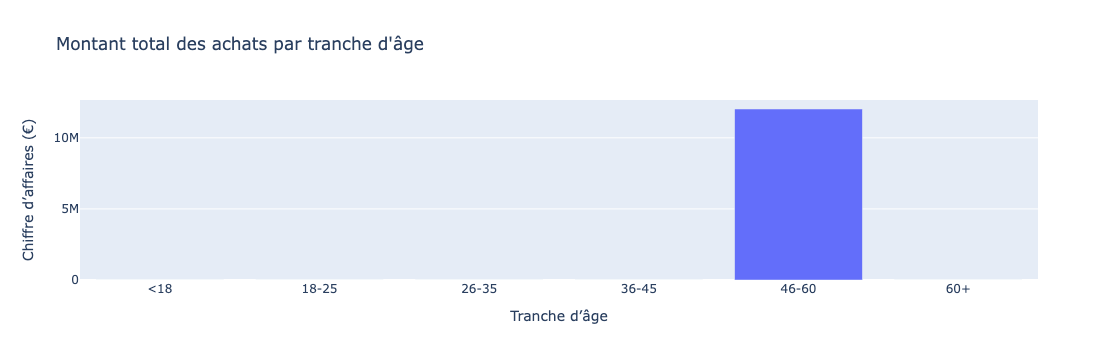

In [71]:
fig = px.bar(
    ca_age,
    x='tranche_age',
    y='ca',
    title="Montant total des achats par tranche d'âge",
    labels={'tranche_age': 'Tranche d’âge', 'ca': 'Chiffre d’affaires (€)'}
)
fig.show()


<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; "> 
Relation entre l’âge et la fréquence d’achat
 </h2>
</div>

In [72]:
frequence_achat = df.groupby('client_id').agg({
    'id_prod': 'count',  
    'age': 'first'      
}).rename(columns={'id_prod': 'nb_achats'}).reset_index()

# Création de tranches d’âge
frequence_achat['tranche_age'] = pd.cut(frequence_achat['age'], bins=bins, labels=labels, right=False)

# Moyenne du nombre d’achats par tranche d’âge
frequence_par_age = frequence_achat.groupby('tranche_age')['nb_achats'].mean().reset_index()


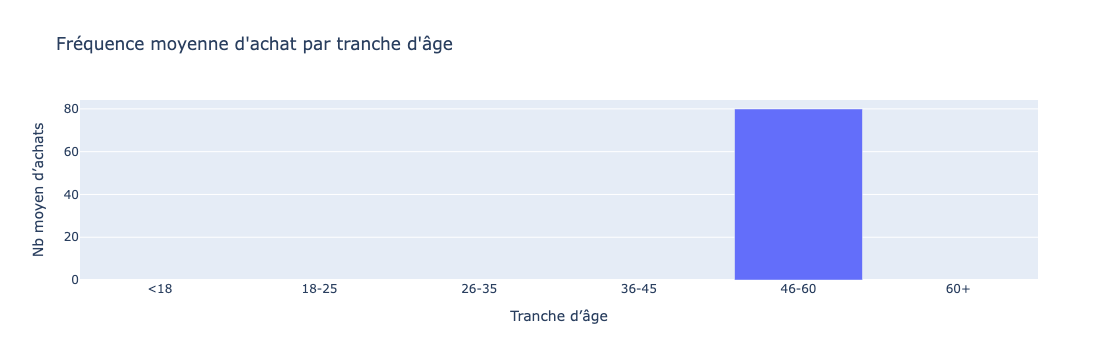

In [73]:
fig = px.bar(
    frequence_par_age,
    x='tranche_age',
    y='nb_achats',
    title="Fréquence moyenne d'achat par tranche d'âge",
    labels={'tranche_age': 'Tranche d’âge', 'nb_achats': 'Nb moyen d’achats'}
)
fig.show()


<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; "> 
Relation entre l’âge et la taille du panier moyen
 </h2>
</div>

In [74]:
# Calcul du chiffre d’affaires et du nombre d’achats par client
panier = df.groupby('client_id').agg({
    'ca': 'sum',         
    'id_prod': 'count', 
    'age': 'first'
}).reset_index()

# Taille moyenne du panier
panier['taille_panier'] = panier['ca'] / panier['id_prod']

# Création des tranches d’âge
panier['tranche_age'] = pd.cut(panier['age'], bins=bins, labels=labels, right=False)

# Moyenne par tranche d’âge
panier_moyen = panier.groupby('tranche_age')['taille_panier'].mean().reset_index()


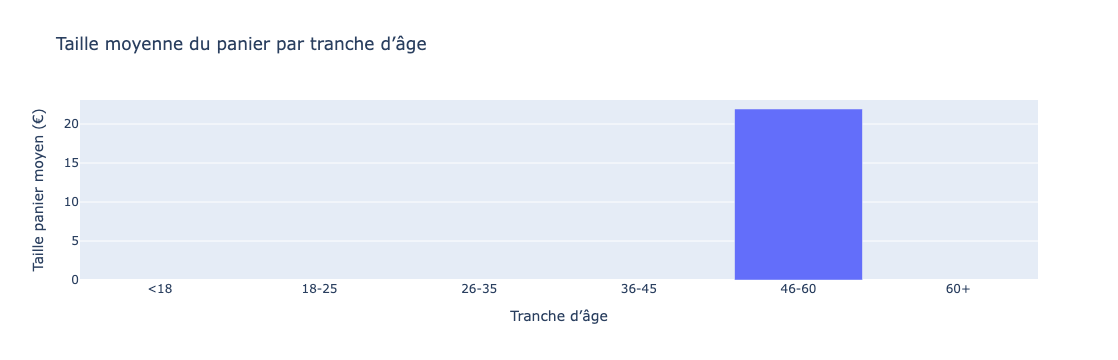

In [75]:
fig = px.bar(
    panier_moyen,
    x='tranche_age',
    y='taille_panier',
    title="Taille moyenne du panier par tranche d’âge",
    labels={'tranche_age': 'Tranche d’âge', 'taille_panier': 'Taille panier moyen (€)'}
)
fig.show()


<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; "> 
 Lien entre l’âge des clients et les catégories de livres achetés
 </h2>
</div>

In [76]:
# Création des tranches d’âge
df['tranche_age'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# Comptage du nombre d’achats par tranche d’âge et par catégorie
age_categ = df.groupby(['tranche_age', 'categ'])['id_prod'].count().reset_index()
age_categ.rename(columns={'id_prod': 'nb_achats'}, inplace=True)


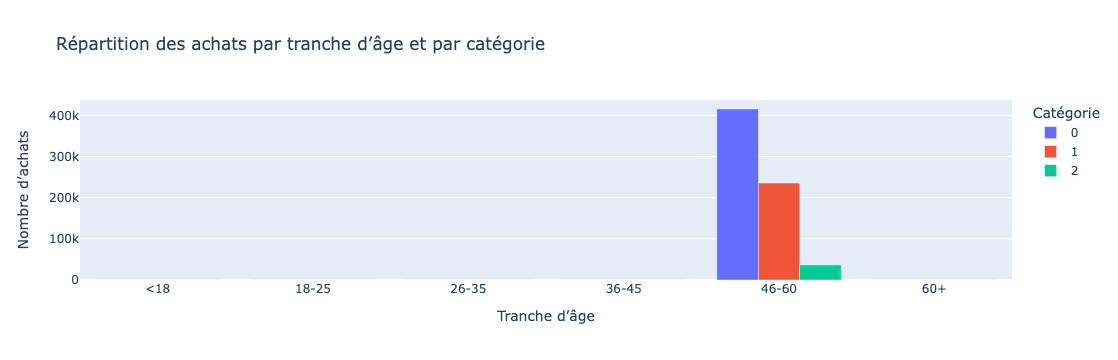

In [77]:

fig = px.bar(
    age_categ,
    x='tranche_age',
    y='nb_achats',
    color='categ',
    barmode='group',
    title="Répartition des achats par tranche d’âge et par catégorie",
    labels={'tranche_age': 'Tranche d’âge', 'nb_achats': 'Nombre d’achats', 'categ': 'Catégorie'}
)
fig.show()


<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; "> 
  Courbe de Lorenz selon les produits
 </h2>
</div>

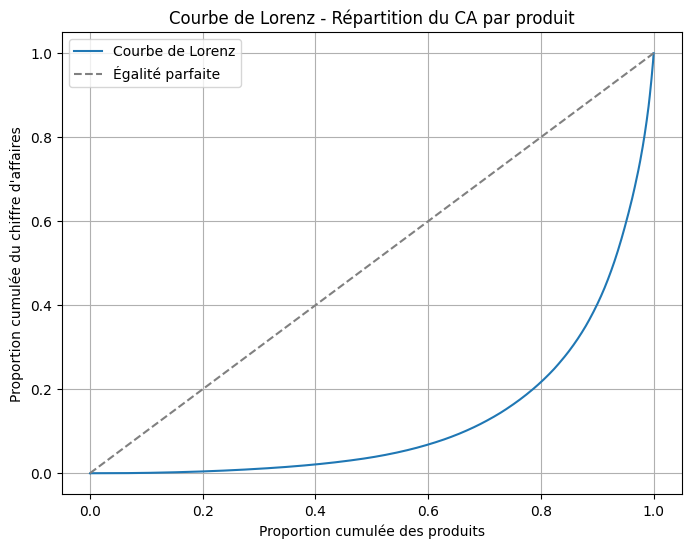

In [78]:
ca_par_produit = df.groupby('id_prod')['ca'].sum().sort_values().reset_index()

# Calcul des valeurs cumulées
ca_par_produit['cumulative_share'] = ca_par_produit['ca'].cumsum() / ca_par_produit['ca'].sum()
ca_par_produit['produit_share'] = np.linspace(0, 1, len(ca_par_produit))

# Ajout du point (0,0)
lorenz_x = np.insert(ca_par_produit['produit_share'].values, 0, 0)
lorenz_y = np.insert(ca_par_produit['cumulative_share'].values, 0, 0)

# Affichage
plt.figure(figsize=(8,6))
plt.plot(lorenz_x, lorenz_y, label="Courbe de Lorenz")
plt.plot([0,1], [0,1], linestyle='--', color='gray', label="Égalité parfaite")
plt.title("Courbe de Lorenz - Répartition du CA par produit")
plt.xlabel("Proportion cumulée des produits")
plt.ylabel("Proportion cumulée du chiffre d'affaires")
plt.legend()
plt.grid()
plt.show()


<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; "> 
 Évolution du chiffre d’affaires dans le temps

 </h2>
</div>

In [79]:
#
df['date'] = pd.to_datetime(df['date'])
df['date'] = pd.to_datetime(df['date'])

### DAILY SALES ###
daily_sales = df.resample('D', on='date')['price'].sum().reset_index()
daily_sales.rename(columns={'price': 'total_sales'}, inplace=True)
daily_sales['daily_avg'] = daily_sales['total_sales'].rolling(window=2).mean()


### WEEKLY SALES ###
weekly_sales = df.resample('W-Mon', on='date')['price'].sum().reset_index()
weekly_sales.rename(columns={'price': 'total_sales'}, inplace=True)
weekly_sales['weekly_avg'] = weekly_sales['total_sales'].rolling(window=2).mean()


### MONTHLY SALES ###
monthly_sales = df.resample('M', on='date')['price'].sum().reset_index()
monthly_sales.rename(columns={'price': 'total_sales'}, inplace=True)
monthly_sales['monthly_avg'] = monthly_sales['total_sales'].rolling(window=2).mean()



display(daily_sales)


,date,total_sales,daily_avg
0,2021-03-01,16565.22,NaN
1,2021-03-02,15486.45,16025.835
2,2021-03-03,15198.69,15342.570
3,2021-03-04,15196.07,15197.380
4,2021-03-05,17471.37,16333.720
...,...,...,...
725,2023-02-24,15207.89,15224.965
726,2023-02-25,15761.25,15484.570
727,2023-02-26,16304.72,16032.985
728,2023-02-27,19170.81,17737.765


In [80]:
daily_sales['date'] = pd.to_datetime(daily_sales['date'], errors='coerce')

daily_sales = daily_sales.dropna(subset=['date'])

# Filter for October 2021
october_sales = daily_sales[
    (daily_sales['date'].dt.year == 2021) & 
    (daily_sales['date'].dt.month == 10)
]

october_sales

,date,total_sales,daily_avg
214,2021-10-01,19052.43,18590.220
215,2021-10-02,22382.43,20717.430
216,2021-10-03,20528.60,21455.515
217,2021-10-04,20211.21,20369.905
218,2021-10-05,18749.91,19480.560
219,2021-10-06,20104.83,19427.370
220,2021-10-07,17366.23,18735.530
221,2021-10-08,18750.09,18058.160
222,2021-10-09,17237.10,17993.595
223,2021-10-10,15746.42,16491.760


In [81]:
# ا
top_clients = df.groupby('client_id')['ca'].sum().sort_values(ascending=False).head(4)
print(top_clients)


client_id
c_1609    326039.89
c_4958    290227.03
c_6714    153918.60
c_3454    114110.57
Name: ca, dtype: float64


In [82]:
print(df.columns)


Index(['id_prod', 'date', 'session_id', 'client_id', 'price', 'categ', 'sex',
       'birth', '_merge', 'ca', 'jour', 'semaine', 'mois', 'age',
       'tranche_age'],
      dtype='object')
